## Basic Geographic manipulation with GeoPandas



### Reading SHP files into GeoDataFrame

In [12]:
import geopandas as gpd

fp = "../../data/cantons/swissBOUNDARIES3D_1_3_TLM_KANTONSGEBIET.shp"

# Read file using gpd.read_file()
data = gpd.read_file(fp)
type(data)


geopandas.geodataframe.GeoDataFrame

### Plotting maps from GeoDataFrame

<Axes: >

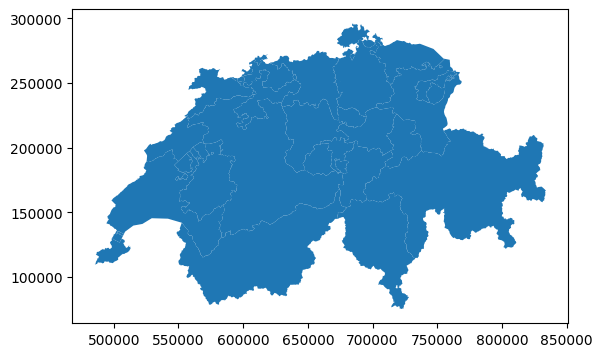

In [13]:
data.plot()

In [14]:
#matplotlib inline

### Basic exploration and navigation

In [15]:
data.head(1)

,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
0,{0B2364ED-49E0-4D53-A33C-C684DD530B57},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,18,NaN,710530.0,0,Graubünden,197888.0,"POLYGON Z ((709776.07 185645.951 3062.876, 709..."


In [16]:
print(data['geometry'].head(1).exterior)

0    LINEARRING Z (709776.07 185645.951 3062.876, 7...
dtype: geometry


<Axes: >

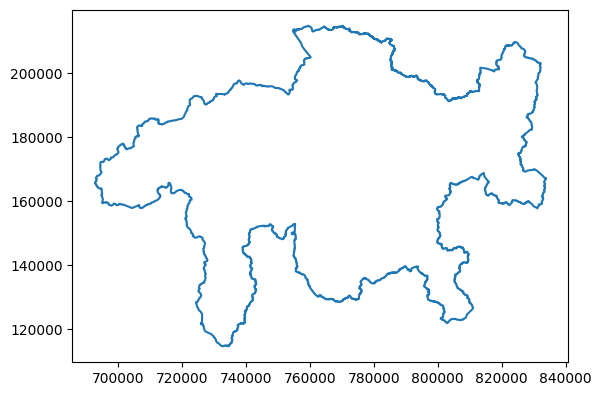

In [17]:
data['geometry'].head(1).exterior.plot()

In [18]:
data['geometry'].head(1).area

0    7.105217e+09
dtype: float64

### Filters and iterations

Select data where the name corresponds to the canton of Vaud

In [19]:
selection=data.loc[data['NAME']=='Vaud']
selection


,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
3,{921DFEF2-6D91-4CB8-9CFC-2A831C412020},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,22,39097.0,321201.0,1,Vaud,793129.0,"POLYGON Z ((549756.794 189303.16 429.247, 5489..."
26,{DAD81A01-85E7-4FFC-B0C9-B2359730300E},2015-12-08,2012-10-26,2012,10,2019,1,Verbessert,AV,2015,...,Kanton,2018_Aufbau,CH,22,NaN,NaN,2,Vaud,NaN,"POLYGON Z ((569696.161 203238.821 428.943, 569..."


In [20]:
for idx,row in selection.iterrows():
    area=row['geometry'].area
    print("The geometry area at {0} is {1}".format(idx,area))

The geometry area at 3 is 3118536618.903036
The geometry area at 26 is 93463290.32157156


<Axes: >

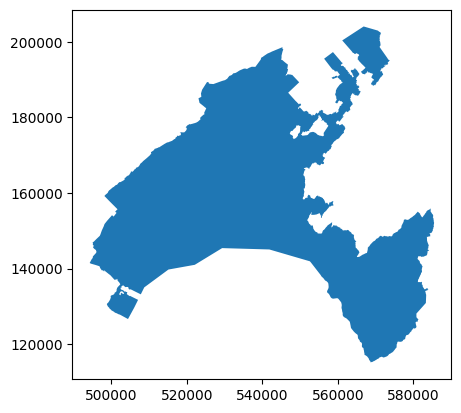

In [21]:
selection.plot()

<Axes: >

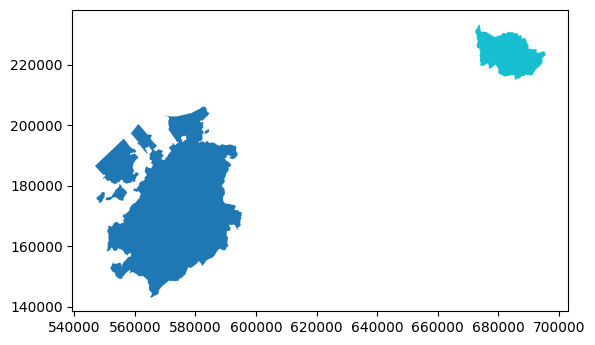

In [22]:
zugAndFribourg=data.loc[(data['NAME']=='Zug') | (data['NAME']=='Fribourg')]
zugAndFribourg.plot('NAME')

In [23]:
zugAndFribourg.explore('NAME')

ImportError: The 'folium', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge folium matplotlib mapclassify' or 'pip install folium matplotlib mapclassify'.

In [24]:
data.explore('NAME')

ImportError: The 'folium', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge folium matplotlib mapclassify' or 'pip install folium matplotlib mapclassify'.

In [17]:

for idx,row in zugAndFribourg.iterrows():
    dist=row['geometry'].distance(data.loc[6]['geometry'])
    print("distance from {0} to {1} is {2}".format(data.loc[8]['NAME'],row['NAME'],dist))

distance from Luzern to Fribourg is 89285.81765415004
distance from Luzern to Zug is 0.0
distance from Luzern to Fribourg is 120366.3759727847
distance from Luzern to Fribourg is 128313.15985575122
distance from Luzern to Fribourg is 135083.44823267878
distance from Luzern to Fribourg is 95400.12430371482
distance from Luzern to Fribourg is 118589.42796294784


In [18]:
for idx,row in zugAndFribourg.iterrows():
    dist=row['geometry'].centroid.distance(data.loc[6]['geometry'].centroid)
    print("distance from {0} to {1} is {2}".format(data.loc[8]['NAME'],row['NAME'],dist))

distance from Luzern to Fribourg is 141967.4230203907
distance from Luzern to Zug is 29767.045955095706
distance from Luzern to Fribourg is 151613.55850258234
distance from Luzern to Fribourg is 156247.23860257282
distance from Luzern to Fribourg is 161859.94375018188
distance from Luzern to Fribourg is 120833.9616898067
distance from Luzern to Fribourg is 143423.81018197164


### Creating a new GeoDataFrame

In [19]:
newData=gpd.GeoDataFrame()
newData['geometry']=None

data['center']=None

data[:3]

/tmp/ipykernel_1579/4093004465.py:2: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  newData['geometry']=None


,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry,center
0,{0B2364ED-49E0-4D53-A33C-C684DD530B57},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,18,NaN,710530.0,0,Graubünden,197888.0,"POLYGON Z ((709776.07 185645.951 3062.876, 709...",None
1,{DDD56CEF-0E61-4EED-85ED-F67A459C93ED},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,2,11897.0,595952.0,1,Bern,1031126.0,"POLYGON Z ((578309.919 203952.588 433.298, 578...",None
2,{54B25E50-30A7-4995-ADE3-5FFF6E13A995},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,23,1060.0,522463.0,0,Valais,341463.0,"POLYGON Z ((679715.071 153452.154 3024.435, 67...",None


In [20]:
for idx,row in data.iterrows():
    center=row['geometry'].centroid
    data.loc[idx,'center']=center
    
data[:5]

,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry,center
0,{0B2364ED-49E0-4D53-A33C-C684DD530B57},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,18,NaN,710530.0,0,Graubünden,197888.0,"POLYGON Z ((709776.07 185645.951 3062.876, 709...",POINT (767575.0244501946 169561.5515886946)
1,{DDD56CEF-0E61-4EED-85ED-F67A459C93ED},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,2,11897.0,595952.0,1,Bern,1031126.0,"POLYGON Z ((578309.919 203952.588 433.298, 578...",POINT (614277.2987648115 185601.5741448295)
2,{54B25E50-30A7-4995-ADE3-5FFF6E13A995},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,23,1060.0,522463.0,0,Valais,341463.0,"POLYGON Z ((679715.071 153452.154 3024.435, 67...",POINT (612816.6401953455 117581.908002399)
3,{921DFEF2-6D91-4CB8-9CFC-2A831C412020},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,22,39097.0,321201.0,1,Vaud,793129.0,"POLYGON Z ((549756.794 189303.16 429.247, 5489...",POINT (539303.7917365739 156760.33692434314)
4,{95F10F52-8B2F-4D6A-AF7E-D4F915E42F89},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,2018_Aufbau,CH,21,7147.0,281216.0,0,Ticino,353709.0,"POLYGON Z ((679715.071 153452.154 3024.435, 67...",POINT (705582.446308137 128055.10893439657)


In [9]:
df=gpd.GeoDataFrame(data.loc[:,['NAME','center']])
df=df.set_geometry("center")
#conversion={'center':'geometry'}
#df.rename(columns=conversion)
df[:5]

KeyError: "['center'] not in index"

### Changing coordinate reference system

In [22]:
df.crs=data.crs

In [23]:
df.crs

<Compound CRS: COMPD_CS["CH1903 / LV03 + LN02 height",PROJCS["CH1 ...>
Name: CH1903 / LV03 + LN02 height
Axis Info [cartesian|vertical]:
- [east]: Easting (metre)
- [north]: Northing (metre)
- [up]: Gravity-related height (metre)
Area of Use:
- undefined
Datum: CH1903
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich
Sub CRS:
- CH1903 / LV03
- LN02 height

<Axes: >

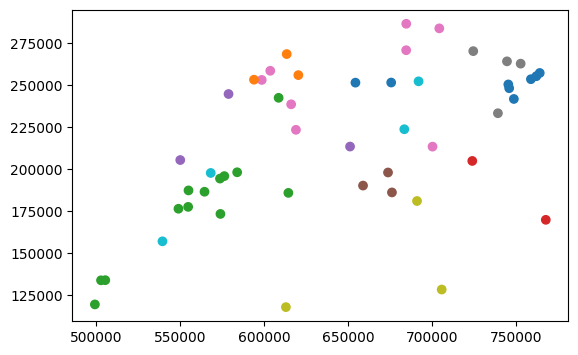

In [24]:
df.plot('NAME')

In [25]:
df.explore()

In [8]:
df_4326 = df.to_crs("EPSG:4326")
df_4326.plot()

NameError: name 'df' is not defined

### Exporting as SHP file

In [26]:
df.to_file('swissCenters.shp')

In [27]:
df.loc[0]

NAME                                       Graubünden
center    POINT (767575.0244501946 169561.5515886946)
Name: 0, dtype: object

In [28]:
firstpoint  = df.loc[0]['center']

In [29]:
#first_point = df["center"].iloc[0]
df["distance"] = df["center"].distance(firstpoint)
df.sort_values(by='distance',ascending=False).head()

,NAME,center,distance
20,Genève,POINT (499072.289 119181.451),273188.347898
45,Genève,POINT (502716.214 133541.703),267296.874678
35,Genève,POINT (505243.183 133632.492),264780.837871
3,Vaud,POINT (539303.792 156760.337),228629.890394
14,Neuchâtel,POINT (549903.555 205160.743),220563.304258


<Axes: >

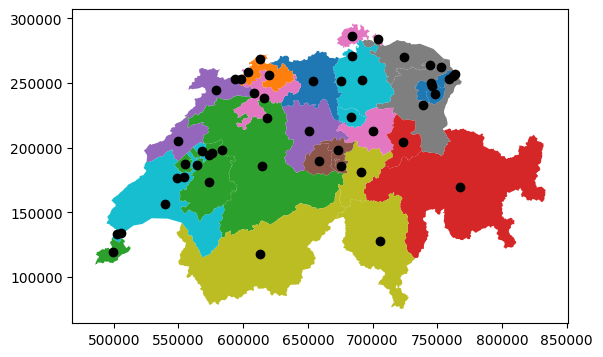

In [31]:
ax = data.plot('NAME')
df.plot(ax=ax, color="black")

/tmp/ipykernel_1579/3380262723.py:2: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  data.loc[data['geometry'].contains(vaud)].plot('KT_TEIL')


<Axes: >

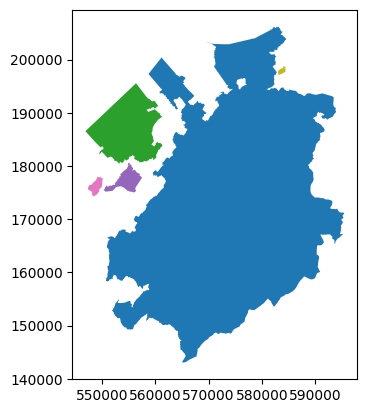

In [57]:
vaud = df.loc[(data['NAME']=="Fribourg")]
data.loc[data['geometry'].contains(vaud)].plot('KT_TEIL')
